# Official HEC-HMS Guide Mirror: GIS Tools and Terrain Data

Official guide: https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/gis-tools-and-terrain-data

This notebook mirrors the official GIS guide category with model-type detection, GIS asset inventory, basin-element parsing, GeoJSON export, and maps of HMS subbasins and stream networks.

In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

logging.disable(logging.CRITICAL)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "hms_commander").is_dir() and (candidate / "examples").is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
WORK_ROOT = REPO_ROOT / "examples" / "working" / "clb238_guides"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
HMS_VERSION = "4.13"

from hms_commander import HmsExamples, HmsPrj

available_versions = HmsExamples.list_versions()
if HMS_VERSION not in available_versions:
    HMS_VERSION = available_versions[0]
HMS_EXE = HmsExamples.get_hms_exe(HMS_VERSION)


def init_sample_project(project_name, notebook_key, overwrite=True):
    project_path = HmsExamples.extract_project(
        project_name,
        version=HMS_VERSION,
        output_path=WORK_ROOT / notebook_key,
        overwrite=overwrite,
    )
    project = HmsPrj()
    project.initialize(project_path, hms_exe_path=HMS_EXE)
    return project, project_path

In [2]:
import geopandas as gpd
from shapely.geometry import Polygon

from hms_commander import HmsBasin, HmsGeo

castro, castro_path = init_sample_project("castro", "103_gis_terrain_data/castro")
river_bend, river_bend_path = init_sample_project("river_bend", "103_gis_terrain_data/river_bend")
tenk, tenk_path = init_sample_project("tenk", "103_gis_terrain_data/tenk")

sample_paths = {"castro": castro_path, "river_bend": river_bend_path, "tenk": tenk_path}
model_types = pd.DataFrame([
    {"sample_project": name, "model_type": HmsGeo.detect_model_type(path)}
    for name, path in sample_paths.items()
])

map_assets = []
for sample_name, sample_path in sample_paths.items():
    maps_dir = sample_path / "maps"
    for suffix in [".shp", ".dbf", ".prj", ".shx", ".grid", ".sqlite"]:
        map_assets.append({
            "sample_project": sample_name,
            "suffix": suffix,
            "count": len(list(maps_dir.glob(f"*{suffix}"))) if maps_dir.exists() else len(list(sample_path.glob(f"*{suffix}"))),
        })
asset_summary = pd.DataFrame(map_assets)
assert asset_summary["count"].sum() > 0

display(model_types)
display(asset_summary.pivot(index="sample_project", columns="suffix", values="count").fillna(0).astype(int))

,sample_project,model_type
0,castro,lumped
1,river_bend,gridded
2,tenk,lumped


suffix,.dbf,.grid,.prj,.shp,.shx,.sqlite
sample_project,,,,,,
castro,2,0,2,2,2,0
river_bend,2,0,2,2,2,0
tenk,2,0,0,2,2,0


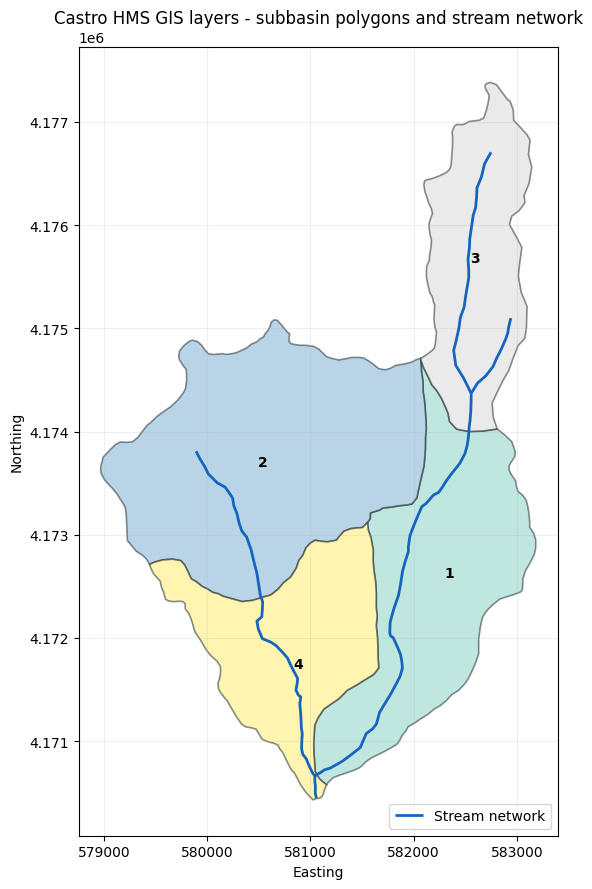

,layer,feature_count,crs
0,subbasin polygons,4,EPSG:26910
1,stream lines,3,EPSG:26910


In [3]:
subbasin_lines = gpd.read_file(castro_path / "maps" / "Subbasins.shp")
rivers = gpd.read_file(castro_path / "maps" / "Rivers.shp")

def closed_line_polygons(gdf):
    polygons = []
    records = []
    for idx, row in gdf.iterrows():
        geom = row.geometry
        if geom.geom_type != "LineString":
            continue
        coords = list(geom.coords)
        if len(coords) < 4:
            continue
        if coords[0] != coords[-1]:
            coords.append(coords[0])
        poly = Polygon(coords)
        if poly.is_valid and not poly.is_empty:
            polygons.append(poly)
            records.append({"subbasin_id": idx + 1, "area_sq_units": poly.area})
    return gpd.GeoDataFrame(records, geometry=polygons, crs=gdf.crs)

subbasin_polygons = closed_line_polygons(subbasin_lines)
assert not subbasin_polygons.empty

fig, ax = plt.subplots(figsize=(8, 9))
subbasin_polygons.plot(ax=ax, column="subbasin_id", cmap="Set3", alpha=0.55, edgecolor="#263238", linewidth=1.2)
rivers.plot(ax=ax, color="#1565c0", linewidth=2.0, label="Stream network")
for _, row in subbasin_polygons.iterrows():
    point = row.geometry.representative_point()
    ax.text(point.x, point.y, str(int(row["subbasin_id"])), ha="center", va="center", fontsize=10, weight="bold")
ax.set_title("Castro HMS GIS layers - subbasin polygons and stream network")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "layer": ["subbasin polygons", "stream lines"],
    "feature_count": [len(subbasin_polygons), len(rivers)],
    "crs": [str(subbasin_polygons.crs), str(rivers.crs)],
})

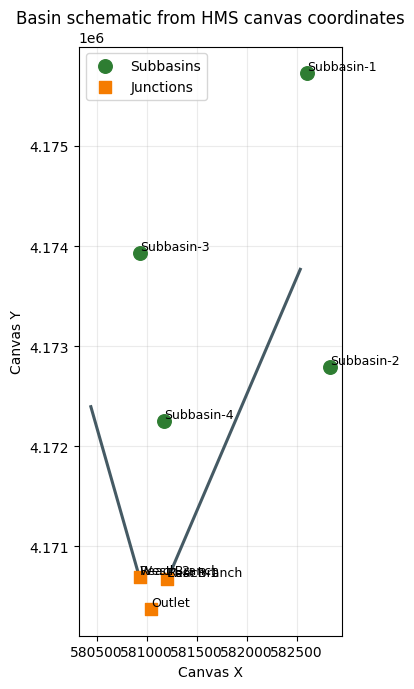

,element_type,count
0,subbasins,4
1,junctions,3
2,reaches,2


In [4]:
basin_path = Path(castro.basin_df.iloc[0]["full_path"])
subbasins = HmsBasin.get_subbasins(basin_path)
junctions = HmsBasin.get_junctions(basin_path)
reaches = HmsBasin.get_reaches(basin_path)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(subbasins["canvas_x"], subbasins["canvas_y"], s=95, color="#2e7d32", label="Subbasins", zorder=3)
ax.scatter(junctions["canvas_x"], junctions["canvas_y"], s=80, color="#f57c00", marker="s", label="Junctions", zorder=3)
for _, reach in reaches.iterrows():
    ax.plot(
        [reach["from_canvas_x"], reach["canvas_x"]],
        [reach["from_canvas_y"], reach["canvas_y"]],
        color="#455a64",
        linewidth=2.2,
        zorder=2,
    )
    ax.text(reach["canvas_x"], reach["canvas_y"], reach["name"], fontsize=9, ha="left", va="bottom")
for _, row in subbasins.iterrows():
    ax.text(row["canvas_x"], row["canvas_y"], row["name"], fontsize=9, ha="left", va="bottom")
for _, row in junctions.iterrows():
    ax.text(row["canvas_x"], row["canvas_y"], row["name"], fontsize=9, ha="left", va="bottom")
ax.set_title("Basin schematic from HMS canvas coordinates")
ax.set_xlabel("Canvas X")
ax.set_ylabel("Canvas Y")
ax.grid(True, alpha=0.25)
ax.legend(loc="best")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

pd.DataFrame([
    {"element_type": "subbasins", "count": len(subbasins)},
    {"element_type": "junctions", "count": len(junctions)},
    {"element_type": "reaches", "count": len(reaches)},
])

In [5]:
gis_output_dir = WORK_ROOT / "103_gis_terrain_data" / "geojson"
gis_outputs = HmsGeo.extract_all_gis(
    basin_path,
    output_dir=gis_output_dir,
    crs_epsg="EPSG:26910",
)
terrain_candidates = [
    path for pattern in ("*.tif", "*.tiff", "*.vrt", "*.dem")
    for path in castro_path.rglob(pattern)
]
output_summary = pd.DataFrame([
    {"layer": layer, "file": path.name, "exists": path.exists(), "size_kb": round(path.stat().st_size / 1024, 1)}
    for layer, path in sorted(gis_outputs.items())
])
terrain_summary = pd.DataFrame([{
    "terrain_rasters_found": len(terrain_candidates),
    "note": "The HMS 4.13 sample project includes vector GIS layers but no DEM raster.",
}])
assert output_summary["exists"].all()
display(output_summary)
display(terrain_summary)

,layer,file,exists,size_kb
0,junctions,hms_junctions.geojson,True,1.1
1,reaches,hms_reaches.geojson,True,1.1
2,subbasins,hms_subbasins.geojson,True,1.6


,terrain_rasters_found,note
0,0,The HMS 4.13 sample project includes vector GI...


## Coverage Notes

The official GIS category also covers georeferencing, terrain preprocessing, linking terrain data, delineation, and terrain-derived parameter estimation. The HMS sample data used here includes vector map layers but no DEM raster, so the notebook renders the available basin boundary and stream GIS layers and records the terrain-data gap explicitly.